In [1]:
import sys
print(sys.executable)
# 导入库
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd 

plt.style.use('seaborn')  # 改变图像风格
# plt.close("all")
plt.rcParams['font.family'] = ['Microsoft Yahei', 'SimHei', 'sans-serif']  # 解决中文乱码
# plt.rcParams['axes.unicode_minus'] = False  # simhei黑体字 负号乱码 解决
plt.rcParams['font.sans-serif'] = ['SimHei'] # Matplotlib中设置字体-黑体，解决Matplotlib中文乱码问题 plt.rcParams['axes.unicode_minus'] = False # 解决Matplotlib坐标轴负号'-'显示为方块的问题

E:\software\anaconda\envs\tree_env\python.exe


C:\Users\yuanjun\AppData\Local\Temp\5\ipykernel_10932\489717603.py:8: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')  # 改变图像风格


In [2]:
statistic_info = pd.read_csv("statistic_result.csv")

In [24]:
statistic_info.columns

Index(['Unnamed: 0', '最小样本数量', '费用类型', '记录总数', '统计特征长度', '原始训练数据量', '原始验证数据量',
       '训练数据可预测数据量', '测试数据可预测数据量', '训练数据可预测数据的均方差', '测试数据可预测数据的均方差',
       '训练数据可预测数据的O/E标准差', '测试数据可预测数据的O/E标准差', '训练数据可预测数据O/E均值',
       '测试数据可预测数据O/E均值', '可预测训练数据占比', '可预测测试数据占比'],
      dtype='object')

In [4]:
statistic_info["可预测训练数据占比"] = statistic_info["训练数据可预测数据量"]/statistic_info["原始训练数据量"]

In [5]:
statistic_info["可预测测试数据占比"] = statistic_info["测试数据可预测数据量"]/statistic_info["原始验证数据量"]

<AxesSubplot: xlabel='记录总数'>

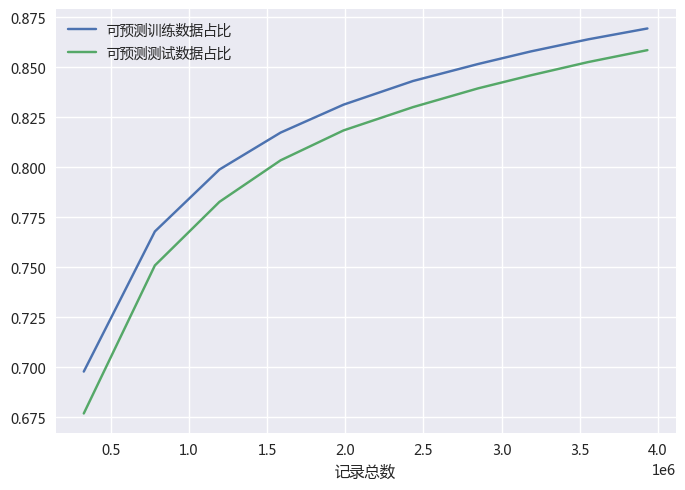

In [20]:
statistic_info[(statistic_info["最小样本数量"]==5) & (statistic_info["费用类型"]=="耗材费") & (statistic_info["统计特征长度"]==8)].plot(x="记录总数", y=["可预测训练数据占比", "可预测测试数据占比"])

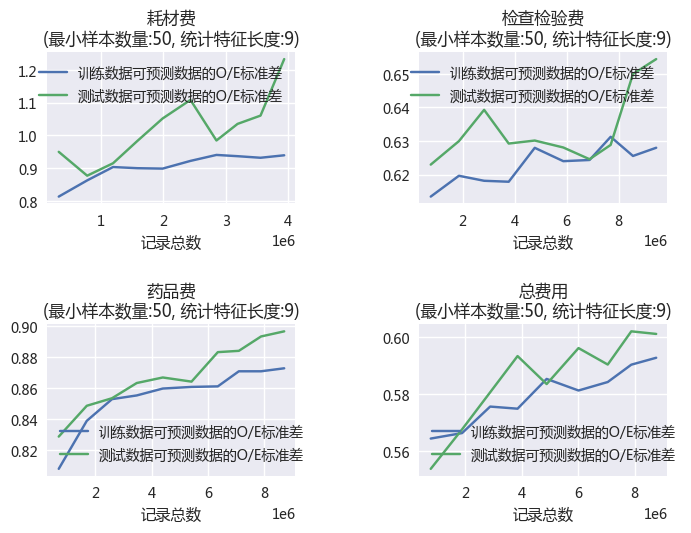

In [39]:
def show_predictable(min_sample_count, feature_encode_level):
    fig, axes = plt.subplots(nrows=2, ncols=2)
    plt.subplots_adjust(wspace=0.5, hspace=0.8)
    statistic_info[(statistic_info["最小样本数量"]==min_sample_count) & (statistic_info["费用类型"]=="耗材费") & (
        statistic_info["统计特征长度"]==feature_encode_level)].plot(x="记录总数", y=["训练数据可预测数据的O/E标准差", "测试数据可预测数据的O/E标准差"], ax=axes[0, 0])
    axes[0, 0].set_title("耗材费\n(最小样本数量:%s, 统计特征长度:%s)" % (min_sample_count, feature_encode_level))
    statistic_info[(statistic_info["最小样本数量"]==min_sample_count) & (statistic_info["费用类型"]=="检查检验费") & (
        statistic_info["统计特征长度"]==feature_encode_level)].plot(x="记录总数", y=["训练数据可预测数据的O/E标准差", "测试数据可预测数据的O/E标准差"], ax=axes[0, 1])
    axes[0, 1].set_title("检查检验费\n(最小样本数量:%s, 统计特征长度:%s)" % (min_sample_count, feature_encode_level))
    statistic_info[(statistic_info["最小样本数量"]==min_sample_count) & (statistic_info["费用类型"]=="药品费") & (
        statistic_info["统计特征长度"]==feature_encode_level)].plot(x="记录总数", y=["训练数据可预测数据的O/E标准差", "测试数据可预测数据的O/E标准差"], ax=axes[1, 0])
    axes[1, 0].set_title("药品费\n(最小样本数量:%s, 统计特征长度:%s)" % (min_sample_count, feature_encode_level))
    statistic_info[(statistic_info["最小样本数量"]==min_sample_count) & (statistic_info["费用类型"]=="总费用") & (
        statistic_info["统计特征长度"]==feature_encode_level)].plot(x="记录总数", y=["训练数据可预测数据的O/E标准差", "测试数据可预测数据的O/E标准差"], ax=axes[1, 1])
    axes[1, 1].set_title("总费用\n(最小样本数量:%s, 统计特征长度:%s)" % (min_sample_count, feature_encode_level))
show_predictable(50, 9)

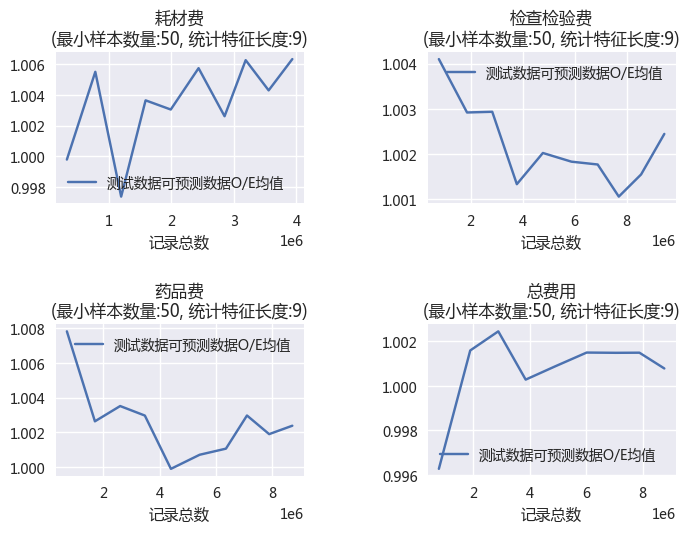

In [34]:
def show_predictable(min_sample_count, feature_encode_level):
    fig, axes = plt.subplots(nrows=2, ncols=2)
    plt.subplots_adjust(wspace=0.5, hspace=0.8)
    statistic_info[(statistic_info["最小样本数量"]==min_sample_count) & (statistic_info["费用类型"]=="耗材费") & (
        statistic_info["统计特征长度"]==feature_encode_level)].plot(x="记录总数", y="测试数据可预测数据O/E均值", ax=axes[0, 0])
    axes[0, 0].set_title("耗材费\n(最小样本数量:%s, 统计特征长度:%s)" % (min_sample_count, feature_encode_level))
    statistic_info[(statistic_info["最小样本数量"]==min_sample_count) & (statistic_info["费用类型"]=="检查检验费") & (
        statistic_info["统计特征长度"]==feature_encode_level)].plot(x="记录总数", y="测试数据可预测数据O/E均值", ax=axes[0, 1])
    axes[0, 1].set_title("检查检验费\n(最小样本数量:%s, 统计特征长度:%s)" % (min_sample_count, feature_encode_level))
    statistic_info[(statistic_info["最小样本数量"]==min_sample_count) & (statistic_info["费用类型"]=="药品费") & (
        statistic_info["统计特征长度"]==feature_encode_level)].plot(x="记录总数", y="测试数据可预测数据O/E均值", ax=axes[1, 0])
    axes[1, 0].set_title("药品费\n(最小样本数量:%s, 统计特征长度:%s)" % (min_sample_count, feature_encode_level))
    statistic_info[(statistic_info["最小样本数量"]==min_sample_count) & (statistic_info["费用类型"]=="总费用") & (
        statistic_info["统计特征长度"]==feature_encode_level)].plot(x="记录总数", y="测试数据可预测数据O/E均值", ax=axes[1, 1])
    axes[1, 1].set_title("总费用\n(最小样本数量:%s, 统计特征长度:%s)" % (min_sample_count, feature_encode_level))
show_predictable(50, 9)

<Figure size 300x2100 with 0 Axes>

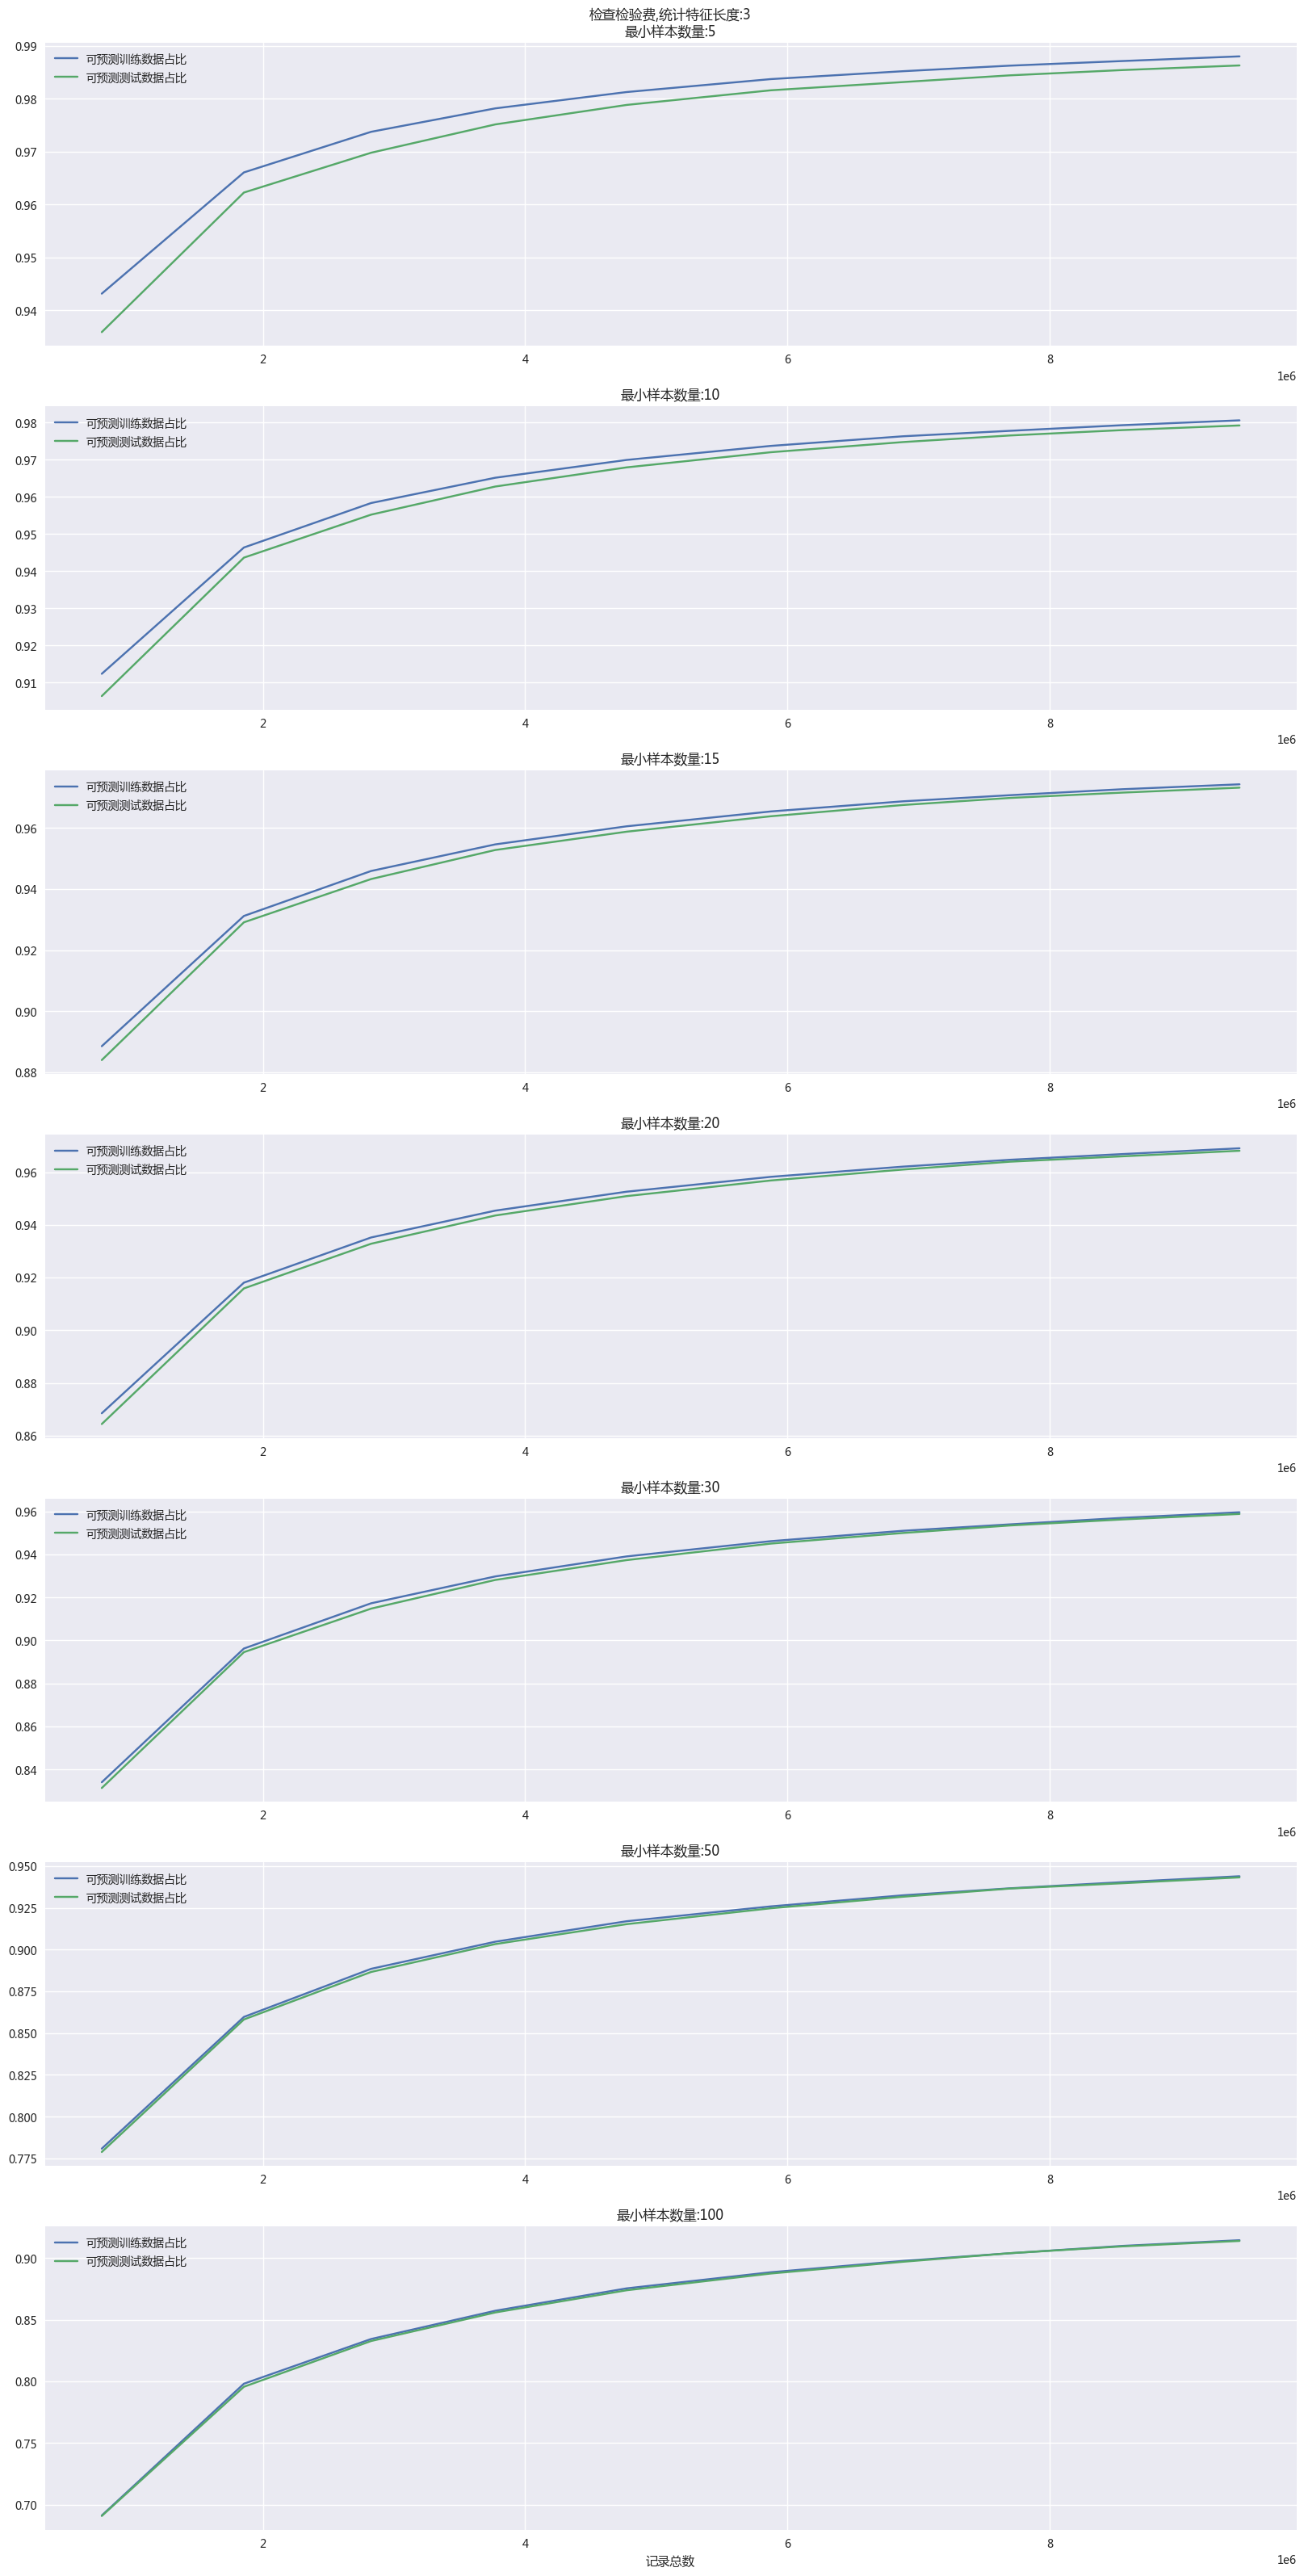

In [12]:
def show_predictable_v2(fee_type, feature_encode_level):
    plt.figure(dpi=300, figsize=(1, 7))
    fig, axes = plt.subplots(nrows=7, ncols=1)
    plt.subplots_adjust(wspace=0.1, hspace=0.2)
    child_pic_x = 20
    child_pic_y = 40
    statistic_info[(statistic_info["最小样本数量"]==5) & (statistic_info["费用类型"]==fee_type) & (
        statistic_info["统计特征长度"]==feature_encode_level)].plot(
        x="记录总数", y=["可预测训练数据占比", "可预测测试数据占比"], ax=axes[0], figsize=(child_pic_x, child_pic_y), xlabel="")
    axes[0].set_title("%s,统计特征长度:%s\n最小样本数量:%s" % (fee_type, feature_encode_level, 5))
    statistic_info[(statistic_info["最小样本数量"]==10) & (statistic_info["费用类型"]==fee_type) & (
        statistic_info["统计特征长度"]==feature_encode_level)].plot(
        x="记录总数", y=["可预测训练数据占比", "可预测测试数据占比"], ax=axes[1], figsize=(child_pic_x, child_pic_y), xlabel="")
    axes[1].set_title("最小样本数量:%s" % 10)
    statistic_info[(statistic_info["最小样本数量"]==15) & (statistic_info["费用类型"]==fee_type) & (
        statistic_info["统计特征长度"]==feature_encode_level)].plot(
        x="记录总数", y=["可预测训练数据占比", "可预测测试数据占比"], ax=axes[2], figsize=(child_pic_x, child_pic_y), xlabel="")
#     axes[2].set_title("%s\n(最小样本数量:%s, 统计特征长度:%s)" % (fee_type, 15, feature_encode_level))
    axes[2].set_title("最小样本数量:%s" % 15)
    statistic_info[(statistic_info["最小样本数量"]==20) & (statistic_info["费用类型"]==fee_type) & (
        statistic_info["统计特征长度"]==feature_encode_level)].plot(
        x="记录总数", y=["可预测训练数据占比", "可预测测试数据占比"], ax=axes[3], figsize=(child_pic_x, child_pic_y), xlabel="")
#     axes[3].set_title("%s\n(最小样本数量:%s, 统计特征长度:%s)" % (fee_type, 20, feature_encode_level))
    axes[3].set_title("最小样本数量:%s" % 20)
    statistic_info[(statistic_info["最小样本数量"]==30) & (statistic_info["费用类型"]==fee_type) & (
        statistic_info["统计特征长度"]==feature_encode_level)].plot(
        x="记录总数", y=["可预测训练数据占比", "可预测测试数据占比"], ax=axes[4], figsize=(child_pic_x, child_pic_y), xlabel="")
#     axes[4].set_title("%s\n(最小样本数量:%s, 统计特征长度:%s)" % (fee_type, 30, feature_encode_level))
    axes[4].set_title("最小样本数量:%s" % 30)
    statistic_info[(statistic_info["最小样本数量"]==50) & (statistic_info["费用类型"]==fee_type) & (
        statistic_info["统计特征长度"]==feature_encode_level)].plot(
        x="记录总数", y=["可预测训练数据占比", "可预测测试数据占比"], ax=axes[5], figsize=(child_pic_x, child_pic_y), xlabel="")
#     axes[5].set_title("%s\n(最小样本数量:%s, 统计特征长度:%s)" % (fee_type, 50, feature_encode_level))
    axes[5].set_title("最小样本数量:%s" % 50)
    statistic_info[(statistic_info["最小样本数量"]==100) & (statistic_info["费用类型"]==fee_type) & (
        statistic_info["统计特征长度"]==feature_encode_level)].plot(
        x="记录总数", y=["可预测训练数据占比", "可预测测试数据占比"], ax=axes[6], figsize=(child_pic_x, child_pic_y))
#     axes[6].set_title("%s\n(最小样本数量:%s, 统计特征长度:%s)" % (fee_type, 100, feature_encode_level))
    axes[6].set_title("最小样本数量:%s" % 100)
show_predictable_v2("检查检验费", 3)

In [2]:
from report import *
Report.statistic_method_problem_show()

cleaned_202202.csv (837772, 12)
cleaned_202203.csv (1171377, 12)
cleaned_202204.csv (1049944, 12)
cleaned_202205.csv (1025316, 12)
cleaned_202206.csv (1089979, 12)
cleaned_202207.csv (1196804, 12)
cleaned_202208.csv (1097764, 12)
cleaned_202209.csv (883855, 12)
cleaned_202210.csv (937427, 12)
cleaned_202211.csv (975983, 12)
cleaned_202212.csv (986561, 12)
month 2 (837772, 27)
耗材费


E:\work_space\yuanjun\SuperviserProject\report.py:409: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  current_label_analysis_df = current_analysis_df[current_analysis_df[label] > 200][current_analysis_df["basy_sjzy"] > 1]


耗材费 2 (327037, 27)


E:\work_space\yuanjun\SuperviserProject\report.py:409: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  current_label_analysis_df = current_analysis_df[current_analysis_df[label] > 200][current_analysis_df["basy_sjzy"] > 1]


耗材费 2 (327037, 27)


...

总费用 2 (787586, 27)


E:\work_space\yuanjun\SuperviserProject\report.py:409: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  current_label_analysis_df = current_analysis_df[current_analysis_df[label] > 200][current_analysis_df["basy_sjzy"] > 1]


总费用 2 (787586, 27)
month 3 (2009149, 27)
耗材费


E:\work_space\yuanjun\SuperviserProject\report.py:409: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  current_label_analysis_df = current_analysis_df[current_analysis_df[label] > 200][current_analysis_df["basy_sjzy"] > 1]


IndexError: indices are out-of-bounds

In [2]:
from report import *
report_tool = Report(label_type="耗材费")

cleaned_202202.csv (837772, 16)
cleaned_202203.csv (1171377, 16)
cleaned_202204.csv (1049944, 16)
cleaned_202205.csv (1025316, 16)
cleaned_202206.csv (1089979, 16)
cleaned_202207.csv (1196804, 16)


In [33]:
report_tool.all_df[report_tool.all_df["basy_sjzy"] < 2].shape

(50133, 46)

In [3]:
report_tool.train.columns.tolist()

['basy_xb',
 'basy_csrq',
 'basy_rysj',
 'basy_cysj',
 'basy_sjzy',
 'basy_zyzd_jbbm',
 'basy_zyzd_jbbm1',
 'basy_zyzd_jbbm2',
 'basy_zyzd_jbbm3',
 'basy_zyzd_jbbm4',
 'basy_ssjczbm1',
 'basy_yydj',
 '耗材费',
 '检查检验费',
 '药品费',
 '总费用',
 'basy_zyzd_jbbm_3',
 'basy_zyzd_jbbm_for_str_3',
 'basy_ssjczbm1_3',
 'basy_ssjczbm1_for_str_3',
 'basy_zyzd_jbbm_4',
 'basy_zyzd_jbbm_for_str_4',
 'basy_ssjczbm1_4',
 'basy_ssjczbm1_for_str_4',
 'basy_zyzd_jbbm_5',
 'basy_zyzd_jbbm_for_str_5',
 'basy_ssjczbm1_5',
 'basy_ssjczbm1_for_str_5',
 'basy_zyzd_jbbm_6',
 'basy_zyzd_jbbm_for_str_6',
 'basy_ssjczbm1_6',
 'basy_ssjczbm1_for_str_6',
 'basy_zyzd_jbbm_7',
 'basy_zyzd_jbbm_for_str_7',
 'basy_ssjczbm1_7',
 'basy_ssjczbm1_for_str_7',
 'basy_zyzd_jbbm_8',
 'basy_zyzd_jbbm_for_str_8',
 'basy_ssjczbm1_8',
 'basy_ssjczbm1_for_str_8',
 'basy_zyzd_jbbm_9',
 'basy_zyzd_jbbm_for_str_9',
 'basy_ssjczbm1_9',
 'basy_ssjczbm1_for_str_9',
 'age',
 'age_group',
 'count',
 'HAOCAI-3-3-E',
 'JCJY-3-3-E',
 'YP-3-3-E',
 'ZF

In [4]:
_, _, statistic_result = report_tool.yydj_jbbm_ssbm_model("ZFY", 8, 8)
print({"耗材费": "HAOCAI-E", "检查检验费": "JCJY-E", "药品费": "YP-E", "总费用": "ZFY-E", "count": "记录条数"})
statistic_result

valibation: (167555, 151)
val_result: (104502, 151)
train: (670217, 151)
train_result (423813, 151)
{'耗材费': 'HAOCAI-E', '检查检验费': 'JCJY-E', '药品费': 'YP-E', '总费用': 'ZFY-E', 'count': '记录条数'}


{'V_0': (167555, 151),
 'V_1': (104502, 151),
 'VAL_RMSE': 5709.6020544898565,
 'VAL_MOE': 1.00270997590165,
 'VAL_STD': 0.6007929933000167,
 'VAL_MAX': 23.54357537253511,
 'T_0': (670217, 151),
 'T_1': (423813, 151),
 'TRAIN_RMSE': 5902.240229214145,
 'TRAIN_MOE': 1.0,
 'TRAIN_STD': 0.578040148234185,
 'TRAIN_MAX': 35.960591257490734}

In [8]:
# report_tool.train.shape
report_tool.statistic_train.columns

Index(['basy_xb', 'basy_csrq', 'basy_rysj', 'basy_cysj', 'basy_sjzy',
       'basy_zyzd_jbbm', 'basy_zyzd_jbbm1', 'basy_zyzd_jbbm2',
       'basy_zyzd_jbbm3', 'basy_zyzd_jbbm4', 'basy_ssjczbm1', 'basy_yydj',
       'HAOCAI', 'JCJY', 'YP', 'ZFY', 'basy_zyzd_jbbm_3',
       'basy_zyzd_jbbm_for_str_3', 'basy_ssjczbm1_3',
       'basy_ssjczbm1_for_str_3', 'basy_zyzd_jbbm_4',
       'basy_zyzd_jbbm_for_str_4', 'basy_ssjczbm1_4',
       'basy_ssjczbm1_for_str_4', 'basy_zyzd_jbbm_5',
       'basy_zyzd_jbbm_for_str_5', 'basy_ssjczbm1_5',
       'basy_ssjczbm1_for_str_5', 'basy_zyzd_jbbm_6',
       'basy_zyzd_jbbm_for_str_6', 'basy_ssjczbm1_6',
       'basy_ssjczbm1_for_str_6', 'basy_zyzd_jbbm_7',
       'basy_zyzd_jbbm_for_str_7', 'basy_ssjczbm1_7',
       'basy_ssjczbm1_for_str_7', 'basy_zyzd_jbbm_8',
       'basy_zyzd_jbbm_for_str_8', 'basy_ssjczbm1_8',
       'basy_ssjczbm1_for_str_8', 'basy_zyzd_jbbm_9',
       'basy_zyzd_jbbm_for_str_9', 'basy_ssjczbm1_9',
       'basy_ssjczbm1_for_str_9'

In [27]:
basy_list = ["age", "basy_yydj", "basy_xb"]
disease_encode_list = ["basy_zyzd_jbbm_3", "basy_zyzd_jbbm_5", "basy_zyzd_jbbm_6", "basy_zyzd_jbbm_7", "basy_zyzd_jbbm_8", 
                       "basy_zyzd_jbbm_9"]
operation_encode_list = ["basy_ssjczbm1_3", "basy_ssjczbm1_5", "basy_ssjczbm1_6", "basy_ssjczbm1_7", "basy_ssjczbm1_8", "basy_ssjczbm1_9"]
disease_e_list = ["ZFY-3-3-E", "ZFY-5-5-E","ZFY-6-6-E","ZFY-7-7-E","ZFY-8-8-E", "ZFY-9-9-E", "ZFY-3-only_disease-E", 
                  "ZFY-4-only_disease-E", "ZFY-5-only_disease-E", "ZFY-6-only_disease-E", "ZFY-7-only_disease-E", "ZFY-8-only_disease-E",
                 "ZFY-only_operation-3-E", "ZFY-only_operation-4-E", "ZFY-only_operation-5-E", "ZFY-only_operation-6-E", 
                  "ZFY-only_operation-7-E", "ZFY-only_operation-8-E"]
feature_list = basy_list + disease_encode_list + disease_e_list + operation_encode_list
category_feature = ["basy_xb"] + disease_encode_list + operation_encode_list
# report_tool.statistic_train, report_tool.statistic_val
report_tool.train = report_tool.train.rename(
            columns={"耗材费": "HAOCAI", "检查检验费": "JCJY", "药品费": "YP", "总费用": "ZFY", "count": "记录条数"})
report_tool.validation = report_tool.validation.rename(
            columns={"耗材费": "HAOCAI", "检查检验费": "JCJY", "药品费": "YP", "总费用": "ZFY", "count": "记录条数"})
train_info, result_info = report_tool.show_train_model(report_tool.statistic_train, report_tool.statistic_val, feature_list, category_feature, 
                                                       "ZFY",
                                                      p_max_depth=6, p_num_leaves=32, p_min_data_in_leaf=10, p_learning_rate=0.1,
                         p_min_sum_hessian_in_leaf=5,  p_lambda_l2=0.2, num_boost_round=150)

E:\software\anaconda\envs\tree_env\lib\site-packages\lightgbm\engine.py:239: UserWarning: 'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. Pass 'log_evaluation()' callback via 'callbacks' argument instead.
  _log_warning("'verbose_eval' argument is deprecated and will be removed in a future release of LightGBM. "
E:\software\anaconda\envs\tree_env\lib\site-packages\lightgbm\basic.py:1780: UserWarning: Overriding the parameters from Reference Dataset.
  _log_warning('Overriding the parameters from Reference Dataset.')
E:\software\anaconda\envs\tree_env\lib\site-packages\lightgbm\basic.py:1513: UserWarning: categorical_column in param dict is overridden.
  _log_warning(f'{cat_alias} in param dict is overridden.')


[1]	training's rmse: 9102.57	training's oeloss: 9102.57	valid_1's rmse: 8704.69	valid_1's oeloss: 8704.69
[2]	training's rmse: 8589.42	training's oeloss: 8589.42	valid_1's rmse: 8202.5	valid_1's oeloss: 8202.5
[3]	training's rmse: 8148.66	training's oeloss: 8148.66	valid_1's rmse: 7773.16	valid_1's oeloss: 7773.16
[4]	training's rmse: 7773.14	training's oeloss: 7773.14	valid_1's rmse: 7408.36	valid_1's oeloss: 7408.36
[5]	training's rmse: 7453.71	training's oeloss: 7453.71	valid_1's rmse: 7099.67	valid_1's oeloss: 7099.67
[6]	training's rmse: 7183.95	training's oeloss: 7183.95	valid_1's rmse: 6840.25	valid_1's oeloss: 6840.25
[7]	training's rmse: 6954.1	training's oeloss: 6954.1	valid_1's rmse: 6625.29	valid_1's oeloss: 6625.29
[8]	training's rmse: 6763.67	training's oeloss: 6763.67	valid_1's rmse: 6444.28	valid_1's oeloss: 6444.28
[9]	training's rmse: 6602.35	training's oeloss: 6602.35	valid_1's rmse: 6295.62	valid_1's oeloss: 6295.62
[10]	training's rmse: 6468.64	training's oeloss: 6

[79]	training's rmse: 5669.32	training's oeloss: 5669.32	valid_1's rmse: 5642.25	valid_1's oeloss: 5642.25
[80]	training's rmse: 5667.42	training's oeloss: 5667.42	valid_1's rmse: 5640.72	valid_1's oeloss: 5640.72
[81]	training's rmse: 5665.68	training's oeloss: 5665.68	valid_1's rmse: 5640.68	valid_1's oeloss: 5640.68
[82]	training's rmse: 5663.94	training's oeloss: 5663.94	valid_1's rmse: 5641.49	valid_1's oeloss: 5641.49
[83]	training's rmse: 5662.54	training's oeloss: 5662.54	valid_1's rmse: 5641.46	valid_1's oeloss: 5641.46
[84]	training's rmse: 5661.67	training's oeloss: 5661.67	valid_1's rmse: 5641	valid_1's oeloss: 5641
[85]	training's rmse: 5660.9	training's oeloss: 5660.9	valid_1's rmse: 5641.21	valid_1's oeloss: 5641.21
[86]	training's rmse: 5660.07	training's oeloss: 5660.07	valid_1's rmse: 5641.49	valid_1's oeloss: 5641.49
[87]	training's rmse: 5659.39	training's oeloss: 5659.39	valid_1's rmse: 5641.52	valid_1's oeloss: 5641.52
[88]	training's rmse: 5658.13	training's oelo

In [28]:
result_info

{'MODEL_VAL_RMSE': 5643.219031013008,
 'MODEL_TRAIN_RMSE': 5600.500247147685,
 'MODEL_TRAIN_MAX': 30.158615075107168,
 'MODEL_VAL_MOE': 1.0017608685836168,
 'MODEL_VAL_STD': 0.5730445492904984,
 'MODEL_VAL_MAX': 24.184137076123022,
 'MODEL_TRAIN_MOE': 0.9975113006922208,
 'MODEL_TRAIN_STD': 0.538858846034234}

<AxesSubplot: title={'center': 'LOSS'}, xlabel='epoch', ylabel='rmse'>

findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Font family 'Arial Unicode MS' not found.
findfont: Fo

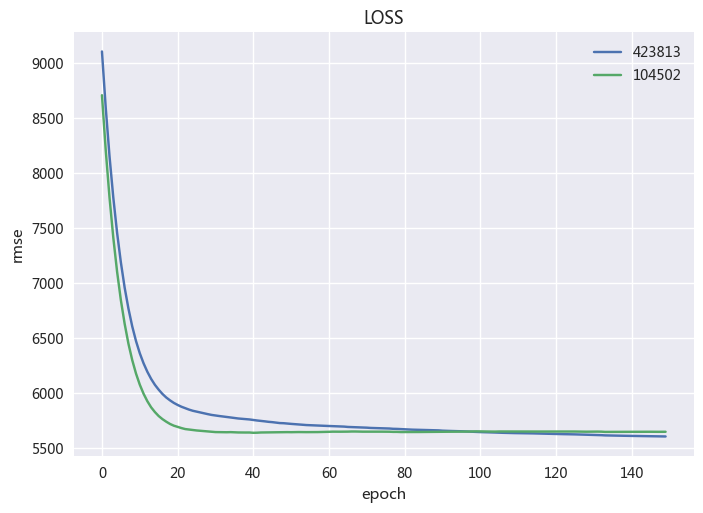

In [29]:
pd.DataFrame(report_tool.loss_metric).plot(xlabel="epoch", ylabel="rmse", title="LOSS")

In [28]:
report_tool.train[report_tool.train["ZFY-8-8-E"].isnull()][
    ["basy_xb", "basy_csrq", "basy_rysj", "basy_cysj", "basy_zyzd_jbbm", "basy_ssjczbm1", "ZFY", "ZFY-3-3-E", "ZFY-4-4-E", "ZFY-7-7-E"]]

,basy_xb,basy_csrq,basy_rysj,basy_cysj,basy_zyzd_jbbm,basy_ssjczbm1,ZFY,ZFY-3-3-E,ZFY-4-4-E,ZFY-7-7-E
0,0,20010811,2022-02-22,2022-02-25,D24.x00,85.2100x003,2077.83,5469.906296,5469.906296,NaN
4,0,19960402,2022-02-26,2022-02-28,O28.300,NaN,1319.44,2325.642000,2325.642000,2325.642000
5,0,19480924,2022-02-08,2022-02-14,S05.300x003,10.6x00x002,3475.28,4282.713750,NaN,NaN
6,0,19510309,2022-02-07,2022-02-23,J96.100,NaN,18559.12,11290.540558,11290.540558,12140.573333
11,0,19531208,2022-02-13,2022-02-19,K91.809,44.1300x001,5774.98,11123.373590,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
670201,0,19621118,2022-02-17,2022-02-23,K40.200x001,17.2400,11021.12,10881.350081,14662.996154,NaN
670207,0,19750429,2022-02-06,2022-02-17,S42.000x021,79.3900x051,20680.08,20275.872941,20772.611654,18685.441299
670210,0,19750810,2022-02-23,2022-02-25,S60.800x043,86.3x02,1864.00,NaN,NaN,NaN
670212,0,19700901,2022-02-22,2022-02-27,E04.101,06.3100x001,14572.69,10323.610763,11068.460260,NaN


In [6]:
def age_distribution(df):
    age_s = df["basy_csrq"].map(lambda a: 2023 - int(str(a)[:4]))
    age_s[age_s.index<90]
    age_value_count_s = age_s.value_counts(normalize=True).sort_index()
    age_value_count_s[age_value_count_s.index<80].plot(xlabel="AGE", ylabel="RATIO", title="耗材年龄人次占比图")

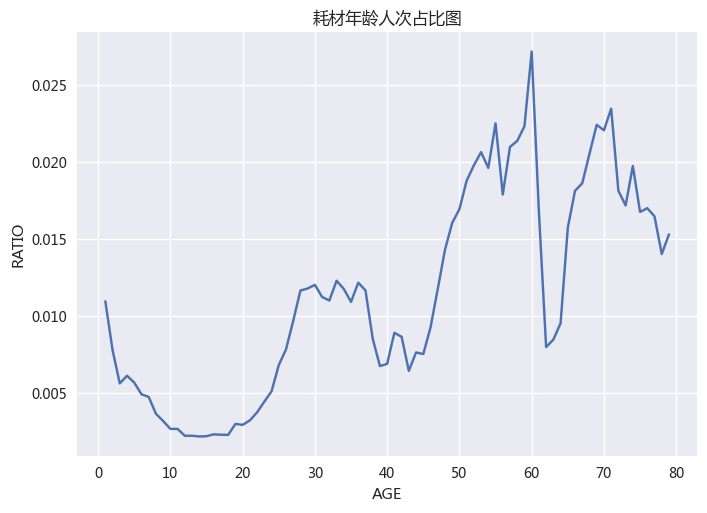

In [7]:
age_distribution(report_tool.all_df)

In [9]:
def age_profile_on_e_groups(df, jb_length=8, ss_length=8, target="总费用", show_pic = True):
    jb_length=8
    ss_length=8
    df["count"] = 1
    df["年龄"] =  df["basy_csrq"].map(lambda a: 2023 - int(str(a)[:4]))
    df["basy_zyzd_jbbm"] = df["basy_zyzd_jbbm"].map(lambda a: a[:jb_length] if isinstance(a, str) else "")
    df["basy_ssjczbm1"] = df["basy_ssjczbm1"].map(lambda a: a[:ss_length] if isinstance(a, str) else "")
    group_statistic = df.groupby(["basy_zyzd_jbbm", "basy_yydj", "basy_ssjczbm1", "年龄"]).agg({
                                                            '耗材费': 'mean',
                                                            '检查检验费': 'mean',
                                                            '药品费': 'mean',
                                                            '总费用': 'mean',
                                                            'count': 'count'}).reset_index()
    group_statistic.sort_values("count", ascending=False ,inplace=True)
    
    age_group_statistic = df.groupby(["basy_zyzd_jbbm", "basy_yydj", "basy_ssjczbm1"]).agg({
                                                            '耗材费': 'mean',
                                                            '检查检验费': 'mean',
                                                            '药品费': 'mean',
                                                            '总费用': 'mean',
                                                            'count': 'count'}).reset_index()
    age_group_statistic = age_group_statistic[age_group_statistic["count"] > 100]
    age_group_statistic.sort_values("count", ascending=False ,inplace=True)
    for i in range(age_group_statistic.shape[0]):
        jbbm = age_group_statistic.iat[i, 0]
        basy_yydj = age_group_statistic.iat[i, 1]
        basy_ssjczbm1 = age_group_statistic.iat[i, 2]
        count = age_group_statistic.iat[i, 7]
        print(jbbm, basy_yydj, basy_ssjczbm1)
        
        age_fee_df = group_statistic[group_statistic["basy_zyzd_jbbm"].isin([jbbm])][group_statistic["basy_yydj"].isin([basy_yydj])][group_statistic["basy_ssjczbm1"].isin([basy_ssjczbm1])]
#         age_fee_df.rename(columns={"耗材费": "HC", "检查检验费": "JCJY", "药品费": "YP", "总费用": "ZFY"}, inplace=True)
        age_fee_df.sort_values("年龄", ascending=False ,inplace=True)
        spearman_value = age_fee_df[["年龄", target]].corr("spearman").iat[0, 1]
        if show_pic:
            age_fee_df.plot(x="年龄", y=target, xlabel="年龄", ylabel="平均 %s" % target, title="spearman_value(%s-%s-%s): %s" % (jbbm, basy_yydj, basy_ssjczbm1, spearman_value))
        yield jbbm, basy_yydj, basy_ssjczbm1, count, spearman_value
gen_pic = age_profile_on_e_groups(report_tool.all_df, target="耗材费")

K63.504 6 45.4300x
('K63.504', 6, '45.4300x', 3384, 0.5265149359886202)


C:\Users\yuanjun\AppData\Local\Temp\5\ipykernel_10932\3290054196.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  age_fee_df = group_statistic[group_statistic["basy_zyzd_jbbm"].isin([jbbm])][group_statistic["basy_yydj"].isin([basy_yydj])][group_statistic["basy_ssjczbm1"].isin([basy_ssjczbm1])]
C:\Users\yuanjun\AppData\Local\Temp\5\ipykernel_10932\3290054196.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_fee_df.sort_values("年龄", ascending=False ,inplace=True)


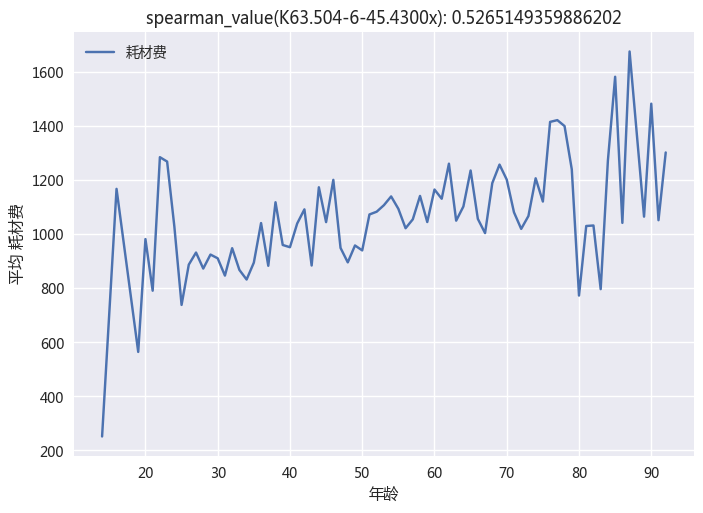

In [56]:
print(next(gen_pic))

In [57]:
def cal_all_spearman():
    spear_list = list()
    gen_pic = age_profile_on_e_groups(report_tool.all_df, target="耗材费", show_pic=False)
    for _, _, _, _, spear in gen_pic:
        spear_list.append(spear)
    return spear_list
spear_list = cal_all_spearman()

Z51.103 6 99.2503


C:\Users\yuanjun\AppData\Local\Temp\5\ipykernel_10932\3290054196.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  age_fee_df = group_statistic[group_statistic["basy_zyzd_jbbm"].isin([jbbm])][group_statistic["basy_yydj"].isin([basy_yydj])][group_statistic["basy_ssjczbm1"].isin([basy_ssjczbm1])]
C:\Users\yuanjun\AppData\Local\Temp\5\ipykernel_10932\3290054196.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_fee_df.sort_values("年龄", ascending=False ,inplace=True)
C:\Users\yuanjun\AppData\Local\Temp\5\ipykernel_10932\3290054196.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  age_fee_df = group_statistic[group_statistic["basy_zyzd_jbbm"].isin([jbbm])][group_statistic["basy_yydj"].isin([basy_yydj])][group_statistic["basy_ssjczbm

K80.101 6 51.2300
H25.900 6 13.4100x
K80.000 6 51.2300


C:\Users\yuanjun\AppData\Local\Temp\5\ipykernel_10932\3290054196.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_fee_df.sort_values("年龄", ascending=False ,inplace=True)
C:\Users\yuanjun\AppData\Local\Temp\5\ipykernel_10932\3290054196.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  age_fee_df = group_statistic[group_statistic["basy_zyzd_jbbm"].isin([jbbm])][group_statistic["basy_yydj"].isin([basy_yydj])][group_statistic["basy_ssjczbm1"].isin([basy_ssjczbm1])]
C:\Users\yuanjun\AppData\Local\Temp\5\ipykernel_10932\3290054196.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
 

Z51.102 6 99.2503
J44.000 6 
N84.001 6 68.2915


...

C:\Users\yuanjun\AppData\Local\Temp\5\ipykernel_10932\3290054196.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  age_fee_df = group_statistic[group_statistic["basy_zyzd_jbbm"].isin([jbbm])][group_statistic["basy_yydj"].isin([basy_yydj])][group_statistic["basy_ssjczbm1"].isin([basy_ssjczbm1])]
C:\Users\yuanjun\AppData\Local\Temp\5\ipykernel_10932\3290054196.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_fee_df.sort_values("年龄", ascending=False ,inplace=True)
C:\Users\yuanjun\AppData\Local\Temp\5\ipykernel_10932\3290054196.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  age_fee_df = group_statistic[group_statistic["basy_zyzd_jbbm"].isin([jbbm])][group_statistic["basy_yydj"].isin([basy_yydj])][group_statistic["basy_ssjczbm

N62.x00x 6 85.2100x
M23.205 6 81.4700x
C16.200 6 43.7x03


C:\Users\yuanjun\AppData\Local\Temp\5\ipykernel_10932\3290054196.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  age_fee_df = group_statistic[group_statistic["basy_zyzd_jbbm"].isin([jbbm])][group_statistic["basy_yydj"].isin([basy_yydj])][group_statistic["basy_ssjczbm1"].isin([basy_ssjczbm1])]
C:\Users\yuanjun\AppData\Local\Temp\5\ipykernel_10932\3290054196.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_fee_df.sort_values("年龄", ascending=False ,inplace=True)
C:\Users\yuanjun\AppData\Local\Temp\5\ipykernel_10932\3290054196.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  age_fee_df = group_statistic[group_statistic["basy_zyzd_jbbm"].isin([jbbm])][group_statistic["basy_yydj"].isin([basy_yydj])][group_statistic["basy_ssjczbm

K25.500x 6 44.4102
H25.900 4 13.4101
K11.603 6 26.2903


C:\Users\yuanjun\AppData\Local\Temp\5\ipykernel_10932\3290054196.py:31: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  age_fee_df = group_statistic[group_statistic["basy_zyzd_jbbm"].isin([jbbm])][group_statistic["basy_yydj"].isin([basy_yydj])][group_statistic["basy_ssjczbm1"].isin([basy_ssjczbm1])]
C:\Users\yuanjun\AppData\Local\Temp\5\ipykernel_10932\3290054196.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  age_fee_df.sort_values("年龄", ascending=False ,inplace=True)


In [90]:
spear_list[-2]

0.16149825783972124

0      -1.000000
1      -1.000000
2      -1.000000
3      -1.000000
4      -0.954545
          ...   
3486         NaN
3487         NaN
3488         NaN
3489         NaN
3490         NaN
Length: 3491, dtype: float64


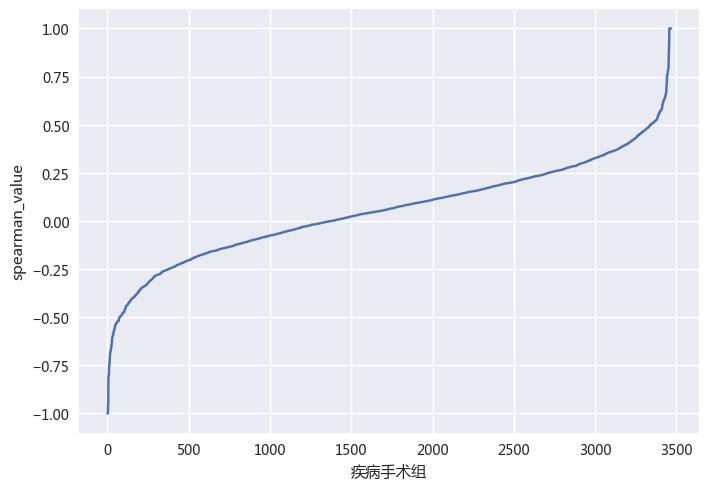

In [58]:
def draw_spear():
#     sorted_list = sorted(spear_list)
#     print(100, sorted_list[100])
#     print(1000, sorted_list[1000])
#     print(4000, sorted_list[4000])
    spear_s = pd.Series(spear_list)
    spear_s.sort_values(inplace=True)
    spear_s = spear_s.reset_index(drop=True)
#     print(1000, spear_s[1000])
#     print(2000, spear_s[2000])
#     print(3000, spear_s[3000])
#     print(4000, spear_s[4000])
    print(spear_s)
    spear_s.plot(xlabel="疾病手术组", ylabel="spearman_value")
draw_spear()

In [71]:
spear_list[12953]

nan

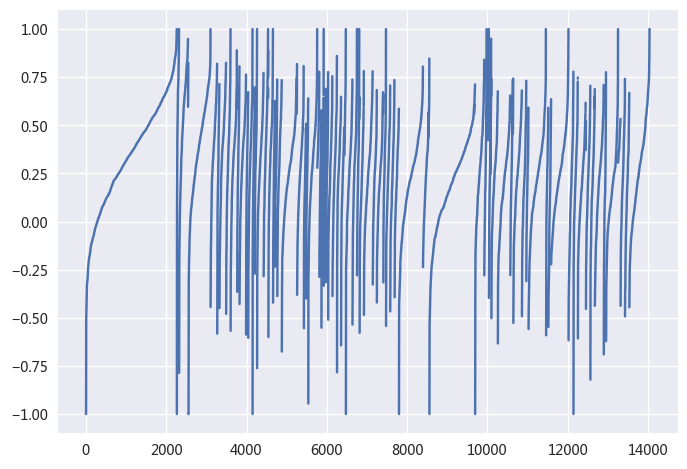

In [59]:
spear_list[:10]
x = range(len(spear_list))
y = spear_list
plt.plot(x, y)

In [ ]:


# 1 准备数据
# 电影名字
movie_name = ['雷神3：诸神黄昏','正义联盟','东方快车谋杀案','寻梦环游记','全球风暴', '降魔传','追捕','七十七天','密战','狂兽','其它']

# 横坐标（X轴坐标）
x = range(len(movie_name))
# 总坐标（Y轴坐标）
y = [73853,57767,22354,15969,14839,8725,8716,8318,7916,6764,52222]

# 2 创建画布
plt.figure(figsize=(20,8),dpi=100)

# 3 绘制
plt.bar(x,y,width=0.5,color=['b','r','g','y','c','m','y','k','c','g','b'])

# 4 辅助显示
# 修改刻度显示
plt.xticks(x,movie_name)
# 增加网格显示
plt.grid(linestyle='--',alpha=0.5)
# 增加标题
plt.title('电影票房收入对比')

# 显示
plt.show()


In [48]:
sample_pb_df = pd.read_csv("statistic_sample_problem_result.csv")

In [49]:
sample_pb_df["最小样本数量"] = sample_pb_df["最小样本数量"].map(lambda a: a.replace("###", "~"))

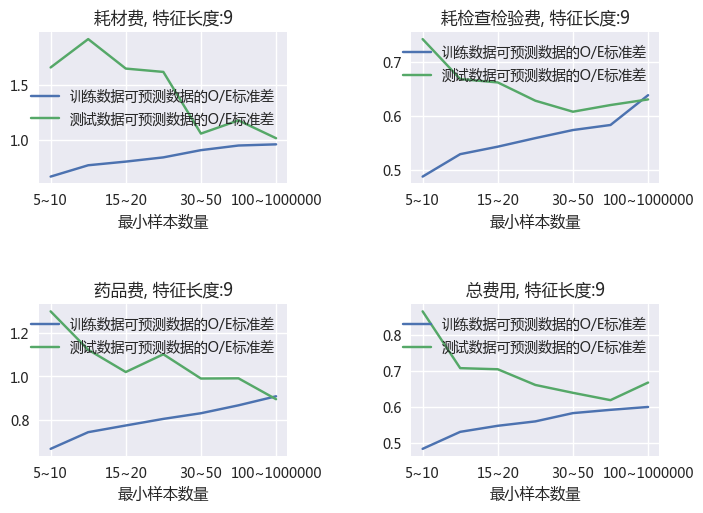

In [69]:

#     statistic_info[(statistic_info["最小样本数量"]==min_sample_count) & (statistic_info["费用类型"]=="耗材费") & (
#         statistic_info["统计特征长度"]==feature_encode_level)].plot(x="记录总数", y="测试数据可预测数据O/E均值", ax=axes[0, 0])
#     axes[0, 0].set_title("耗材费\n(最小样本数量:%s, 统计特征长度:%s)" % (min_sample_count, feature_encode_level))
#     statistic_info[(statistic_info["最小样本数量"]==min_sample_count) & (statistic_info["费用类型"]=="检查检验费") & (
#         statistic_info["统计特征长度"]==feature_encode_level)].plot(x="记录总数", y="测试数据可预测数据O/E均值", ax=axes[0, 1])
#     axes[0, 1].set_title("检查检验费\n(最小样本数量:%s, 统计特征长度:%s)" % (min_sample_count, feature_encode_level))
#     statistic_info[(statistic_info["最小样本数量"]==min_sample_count) & (statistic_info["费用类型"]=="药品费") & (
#         statistic_info["统计特征长度"]==feature_encode_level)].plot(x="记录总数", y="测试数据可预测数据O/E均值", ax=axes[1, 0])
#     axes[1, 0].set_title("药品费\n(最小样本数量:%s, 统计特征长度:%s)" % (min_sample_count, feature_encode_level))
#     statistic_info[(statistic_info["最小样本数量"]==min_sample_count) & (statistic_info["费用类型"]=="总费用") & (
#         statistic_info["统计特征长度"]==feature_encode_level)].plot(x="记录总数", y="测试数据可预测数据O/E均值", ax=axes[1, 1])
#     axes[1, 1].set_title("总费用\n(最小样本数量:%s, 统计特征长度:%s)" % (min_sample_count, feature_encode_level))

def plot_sample_feature_length_rel(feature_len):
    fig, axes = plt.subplots(nrows=2, ncols=2)
    plt.subplots_adjust(wspace=0.5, hspace=0.8)
    sample_pb_df[(sample_pb_df["费用类型"]=="耗材费") & (sample_pb_df["统计特征长度"]==feature_len)].plot(
        x="最小样本数量", y=["训练数据可预测数据的O/E标准差","测试数据可预测数据的O/E标准差"], ax=axes[0, 0])
    axes[0, 0].set_title("耗材费, 特征长度:%s" % feature_len)
    sample_pb_df[(sample_pb_df["费用类型"]=="检查检验费") & (sample_pb_df["统计特征长度"]==feature_len)].plot(
        x="最小样本数量", y=["训练数据可预测数据的O/E标准差","测试数据可预测数据的O/E标准差"], ax=axes[0, 1])
    axes[0, 1].set_title("耗检查检验费, 特征长度:%s" % feature_len)
    sample_pb_df[(sample_pb_df["费用类型"]=="药品费") & (sample_pb_df["统计特征长度"]==feature_len)].plot(
        x="最小样本数量", y=["训练数据可预测数据的O/E标准差","测试数据可预测数据的O/E标准差"], ax=axes[1, 0])
    axes[1, 0].set_title("药品费, 特征长度:%s" % feature_len)
    sample_pb_df[(sample_pb_df["费用类型"]=="总费用") & (sample_pb_df["统计特征长度"]==feature_len)].plot(
        x="最小样本数量", y=["训练数据可预测数据的O/E标准差","测试数据可预测数据的O/E标准差"], ax=axes[1, 1])
    axes[1, 1].set_title("总费用, 特征长度:%s" % feature_len)
plot_sample_feature_length_rel(feature_len=9)

In [60]:
sample_pb_df

,Unnamed: 0,最小样本数量,费用类型,记录总数,统计特征长度,原始训练数据量,原始验证数据量,训练数据可预测数据量,测试数据可预测数据量,训练数据可预测数据的均方差,测试数据可预测数据的均方差,训练数据可预测数据的O/E标准差,测试数据可预测数据的O/E标准差,训练数据可预测数据O/E均值,测试数据可预测数据O/E均值
0,0,5~10,耗材费,4266194,3,3412955,853239,41420,9685,7226.734070,7430.725140,0.827029,3.119992,1.0,1.272199
1,1,10~15,耗材费,4266194,3,3412955,853239,32118,7743,6816.498469,6695.832482,0.979717,3.542763,1.0,1.221362
2,2,15~20,耗材费,4266194,3,3412955,853239,26567,6399,6053.387673,6422.783231,1.043105,4.814735,1.0,1.138029
3,3,20~30,耗材费,4266194,3,3412955,853239,46672,11311,6999.450231,7285.955369,1.097327,2.144195,1.0,1.092595
4,4,30~50,耗材费,4266194,3,3412955,853239,73738,18115,6900.577190,7889.640079,1.221302,1.440862,1.0,1.029257
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,191,15~20,总费用,10607095,9,8485676,2121419,155494,37446,12783.713665,14008.700838,0.548382,0.704618,1.0,1.023423
192,192,20~30,总费用,10607095,9,8485676,2121419,244192,59617,12938.892011,13807.499600,0.560540,0.661250,1.0,1.014581
193,193,30~50,总费用,10607095,9,8485676,2121419,348768,85414,13151.242090,13452.126282,0.583419,0.639528,1.0,1.007755
194,194,50~100,总费用,10607095,9,8485676,2121419,562156,139047,11676.091160,11740.227294,0.592470,0.619269,1.0,1.006459
